**Assignment 2: Processing Datasets in Python**

L, M, V - N1

Olga Regina Charles Moreno 2049291

Luis Fernando Rivera Peregrino 2132271

Luis Gerardo Cordova Herrera 1994989

Evelyn Regina Espinoza Tamez 2049451

In [1]:
# import file to work on.
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


In [2]:
# the dataset is uploaded using pandas.
import pandas as pd

df = pd.read_csv("diabetes.csv")

In [3]:
# visualize the zero values.
df.head()
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [4]:
# how many zeros are on the values.
(df[['Glucose','BloodPressure','SkinThickness','Insulin','BMI']] == 0).sum()

,0
Glucose,5
BloodPressure,35
SkinThickness,227
Insulin,374
BMI,11


In [5]:
# get the statistics.
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# replace zeros by the median.
columns = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in columns:
    df[col] = df[col].replace(0, df[col].median())

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1


In [7]:
# normalize data with minmax scaler.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df_scaled = df.copy()
df_scaled[df.columns] = scaler.fit_transform(df)

df_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,0.352941,0.670968,0.489796,0.304348,0.019832,0.314928,0.234415,0.483333,1.0
1,0.058824,0.264516,0.428571,0.239130,0.019832,0.171779,0.116567,0.166667,0.0
2,0.470588,0.896774,0.408163,0.173913,0.019832,0.104294,0.253629,0.183333,1.0
3,0.058824,0.290323,0.428571,0.173913,0.096154,0.202454,0.038002,0.000000,0.0
4,0.000000,0.600000,0.163265,0.304348,0.185096,0.509202,0.943638,0.200000,1.0


In [8]:
# for data visualization, next libraries.
import matplotlib.pyplot as plt
import seaborn as sns

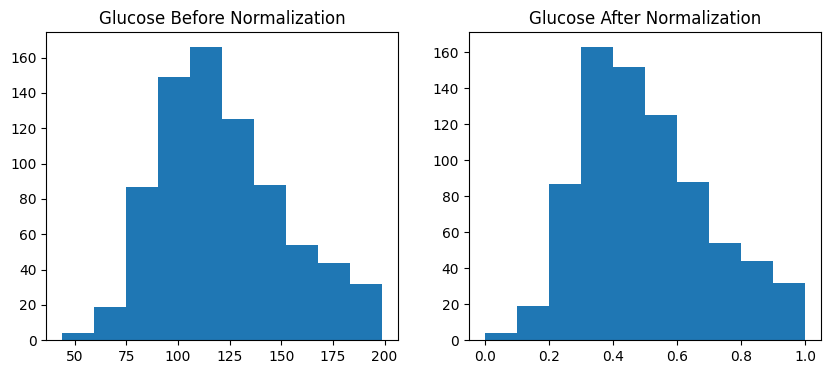

In [9]:
# get the histograms of glucose.
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df['Glucose'])
plt.title("Glucose Before Normalization")

plt.subplot(1,2,2)
plt.hist(df_scaled['Glucose'])
plt.title("Glucose After Normalization")

plt.show()

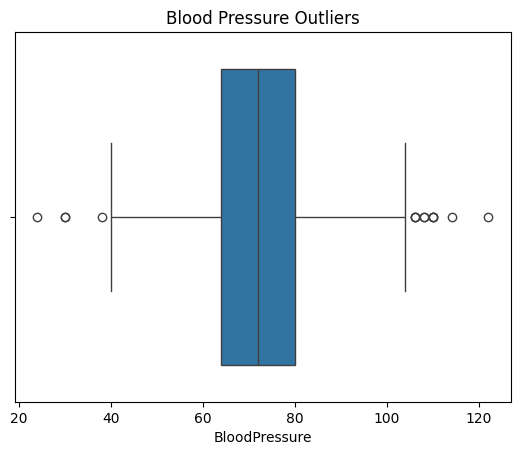

In [10]:
# detect outliers on blood pressure.
sns.boxplot(x=df['BloodPressure'])
plt.title("Blood Pressure Outliers")
plt.show()

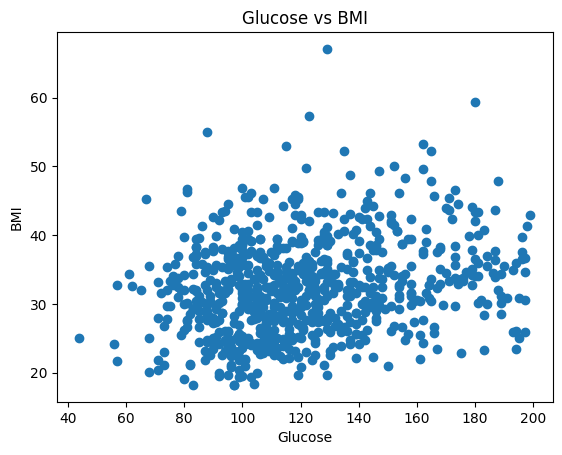

In [11]:
# scatter plot to see relation between glucose and BMI
plt.scatter(df['Glucose'], df['BMI'])
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.title("Glucose vs BMI")
plt.show()

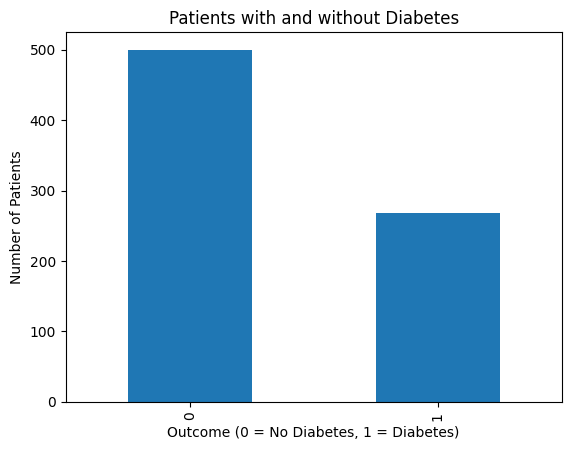

In [12]:
# bar chart of outcome of patients with or without diabetes.
df['Outcome'].value_counts().plot(kind='bar')

plt.title("Patients with and without Diabetes")
plt.xlabel("Outcome (0 = No Diabetes, 1 = Diabetes)")
plt.ylabel("Number of Patients")

plt.show()

**Answers to the questions:**

1. What impact do missing values have on data analysis?

They’re a huge obstacle when processing data because they can either affect the methodology being used to analyse the data, or directly stop the algorithm if it isn’t able to work its way around an empty data space. Elaborating on the first case, an example would be getting the average of a set of numbers, if the set has elements that are in the hundreds or thousands (as in equal to 500, not that there are 500 elements) missing value could be taken as 0 and throw off the average calculated. Say the average of a set of 5 numbers {386, 0, 450, 600, 500} is calculated to be 387.2, the problem is that the only number close to it is 386.

2. How can we detect and handle outliers in biomedical datasets?

A way of detecting them is to set a range of minimum and maximum values that would be considered as normal, so that any number that goes below or above those limits is highlighted as an outlier. For this case though, it is important to have previous experience or background on what values to expect so data that seems to be an outlier but is actually relevant for a reason doesn’t get categorized wrongly. Also, it’s important that outliers are not just erased but rather presented as outliers properly, because they have a reason, be it incorrect sampling or just a strange occurrence.

3. What are some common causes of missing or incorrect data in biomedical studies?

The first mistake that could happen is an incorrect way of getting the data itself. For example, making a survey about quality of life for individuals with prosthetics but the questions are too vague, or there was a spelling error that changed the meaning of a sentence. A lot of variables can go wrong in that initial step, but also, even after getting the data, not processing it with adequate established parameters can affect it too, specially in image processing where visual information is key, like setting a threshold inaccurately and resulting in mixed regions’ borders.

4. How does normalizing data improve the performance of Machine Learning models?

Because a lot of times machine learning models work on the assumption that all the data is adjusted in a suitable condition to work with it, normalizing the data ensures the model can read and process it better. Normalizing is really optimal considering that sometimes data has different scales that  affect values differently so setting them in a unique range proportional to their relationships makes the machine learning model understand it faster to converge, limit how much certain values influence others more sensitive, and appreciate the relatedness between elements better.

5. Why is visualizing data an important step before applying Machine Learning models?
Machine Learning uses a dataset in order to be trained, therefore, the data quality is affecting directly to the algorithm, many problems may rise when feeding data to a machine learning model, such as:
Non representative data: The data does not show the real life situation it tries to describe and because of this the algorithm will not work properly.
Insufficient data: The algorithm will not be able to truly classify the new datasets that it is given, as there was not enough data to properly create a model it can work with.
Not correctly dimensioned data: The data lacks the proper characteristics to be correctly analyzed and implemented on the task it takes a part of, so the algorithm won’t be able to find a proper model.
This problems are solved when we apply a visualization tool on the data we want to feed the model with, it allows us to not make wrong assumptions about the structure of the dataset, it can reveal anomalies within the data so they can be properly taken care of, check if the data is evenly distributed and even looking at the shape of the data could allow us to determine the right model for the application.

6. Why is preprocessing critical when working with medical datasets?
Preprocessing is the cleaning the information, machines used in the medical field often have their own preprocessing methods in order to deal the doctors a clean, noiseless image or data in general, when dealing this data to a machine learning algorithm several other things must be taken in consideration, things such as contrast, machine used for the data acquisition, or other variables within the final data may affect the way our algorithm reads on it.
Then, how can we generalize the data? Preprocessing is the answer, from all the data that is going to be used, we set a number of characteristics such as contrast, size, eliminating “distractions” or non important elements and selecting “healthy” or normal situations to those "abnormal". Preprocessing may be different for every single algorithm, but it is important to apply in these situations as it allows the machine to create a proper model using correctly transformed data.

7. Which ethical concerns should be considered when handling patient data?
The right to confidentiality is the most important one when dealing with patients information, medical files usually contain identifiers for every patient, stripping every trace of identifying data before any other process is a mandatory ethical and legal obligation, this comes with the patients acknowledgement, they must explicitly agree on the way their data will be used, giving consent to share or not the data acquired for training a machine learning model, or basically any other application different from diagnosis.
Another concern in the field is data security, cyber attacks happen almost if not every day, when we store sensitive information about any patient, this information is at risk of being stolen, ensuring the data safety is a must as well as controlling the limited access to this information.

Group conclusion:

This assignment allowed us to bridge the gap between raw clinical data and predictive machine learning models. By analyzing the Pima Indians Diabetes database, our team solidified our technical knowledge of Python libraries such as Pandas, NumPy, and Matplotlib.
Also, we experienced firsthand the complicated reality of working with medical data. We learned the legal and ethical protocols that must be followed during data acquisition and even handling. Additionally, we saw how raw biomedical data is almost never ready for immediate implementation as it requires careful preprocessing to ensure that the data fits a standardized or generalized framework. In a nutshell, this activity demonstrated that effective machine learning relies entirely on ethical, well-executed data preparation, whereas it is acquisition, preprocessing or handling.

